# 뉴스 기사 텍스트 전처리

**과제 내용**

1. 뉴스 기사 하나를 선택해 아래 전처리를 수행
   - 문장 / 단어 토큰화
   - 품사 부착 (PoS Tagging)
   - 개체명 인식 (NER)
   - 원형 복원 (어간 추출 · 표제어 추출)
   - 불용어 처리
2. 전처리 결과 기반 최빈 단어 시각화
3. 전처리 결과에 대한 고찰

---

**분석 대상 기사**

- 제목 : 구글 "대만과 어깨 나란히"…AI 인프라 협력, 발주에서 공동설계로
- 매체 : 지디넷코리아 (네이버 뉴스 IT/과학 제휴 언론사)
- 원문 : https://zdnet.co.kr/view/?no=20260905223908
- 선정 이유 : 기업(구글·엔비디아·미디어텍·TSMC), 인물(아민 바흐다트·순다르 피차이), 지역(대만·타이베이·미국),  
  숫자/단위(39억달러·8세대·60%), 영문 약어(TPU·CTO·R&D) 가 고르게 섞여 있어  
  토큰화 · 개체명 인식 · 불용어 처리의 문제점을 관찰하기 좋음

In [ ]:
# 이론시간에 mecab까지 설치한 가상환경을 최대한 사용하는 것을 추천합니다.
%pip install -q pandas nltk konlpy wordcloud

In [3]:
import re
import warnings
from collections import Counter

import pandas as pd
from konlpy.tag import Okt, Komoran, Hannanum, Kkma

warnings.filterwarnings("ignore")

In [5]:
raw_text = """구글이 대만 공급망과의 관계를 단순 발주·납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다. 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨를 나란히 하고(shoulder to shoulder)"라는 한 마디로 요약했다.

6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포럼 및 글로벌 생태계 서밋에 참석해 강연한 뒤, 대만 언론 인터뷰에 처음으로 응했다. 그는 구글 텐서처리장치(TPU)와 AI 하드웨어 전략의 핵심 설계자로 꼽히는 인물이다. 15년간 구글 AI 인프라 개발에 참여하고 이를 주도해 왔으며, 지난해 말 CTO로 승진해 순다르 피차이 구글 최고경영자(CEO)에게 직접 보고한다.

브로드컴을 통해 개발 및 양산되는 구글의 7세대 TPU 아이언우드. (사진=구글)
이번 방문은 알파벳의 미디어텍 지분 투자와 맞물리며 시장의 주목을 받았다. 업계에서는 그가 행사 전 대만 공급망을 비공개로 방문해 TPU 서버 물량을 논의한 것으로 본다. 다만 바흐다트 CTO는 구체적인 수주나 협력 내용에 대해서는 공개하지 않았다.

미디어텍은 최근 39억달러 규모의 해외 전환사채(CB)를 발행했다. 이 가운데 엔비디아가 35억달러를 인수했고, 알파벳은 남은 물량 인수에 참여했다. 정확한 투자 금액은 공개되지 않았다.

"이미 구매·파트너의 문제가 아니다"…랙 설계까지 함께

바흐다트 CTO가 인터뷰에서 거듭 강조한 것은 협력 방식 자체가 근본적으로 달라졌다는 점이다. 바흐다트 CTO는 "이건 이미 구매와 파트너의 문제가 아니다"라며 구글과 대만 업체들이 이미 깊은 수준의 공동 설계 단계에 들어섰고, 이런 협력이 매달·매 분기·매년 가속되고 있다고 설명했다. 이어 "대만 파트너와 깊이 있는 공동 설계를 하지 않았다면 오늘날과 같은 인프라와 컴퓨팅 플랫폼을 만들어내는 것은 불가능했을 것"이라고 말했다.

그는 구글이 현재 여러 대만 협력사와 차세대 제품을 두고 논의를 진행 중이며, 협력 범위가 랙 레벨(rack level)의 엔드투엔드 아키텍처 설계로까지 확장됐다고 전했다. 양산 설계와 신뢰성 향상 방식 등 대만 공급망의 엔지니어링 실행력이 인상적이었다는 평가도 내놨다.

구글 대만 팀은 구글 AI 하드웨어 개발의 중요한 역할을 맡고 있다. 바흐다트 CTO는 구글의 설계·제조 작업 상당수가 대만에서 이뤄지며, TSMC 생산라인에서 칩이 나오면 대만 팀이 가장 먼저 테스트를 수행하는 경우가 많다고 설명했다. 24시간 가까이 구글과 협력사가 어깨를 맞대고 칩의 정상 작동 여부를 확인한 뒤 최대한 빨리 소프트웨어 개발팀에 넘긴다는 것이다.

대만은 구글이 미국 외 지역에 둔 최대 하드웨어 연구개발(R&D) 거점이다. 바흐다트 CTO는 "타이베이 스린 AI 인프라 R&D 센터의 사무 공간을 60% 확대하고 있으며, 팀 규모도 계속 커질 것"이라고 말했다.

TPU 8t·8i 분리는 2년 전 결정…"다음 전용화는 CPU"

구글은 올해 4월 '클라우드 넥스트' 행사에서 8세대 TPU를 처음으로 두 개의 독립된 칩으로 나눴다. 대규모 학습에 특화된 TPU 8t와 고동시성 추론을 겨냥한 TPU 8i다. 학습용·추론용 칩의 '분가'가 맞춤형 칩의 세분화를 예고하는 것이냐는 질문에 그는 이런 흐름이 "어느 정도는 불가피하다"고 강조했다.

그러면서 "구글은 약 2년 전 이미 학습과 추론 두 워크로드의 수요 규모가 각각 전용 칩을 만들 만큼 커졌다고 판단해 분리를 결정했다"고 말했다. 

바흐다트 CTO는 다음 전용칩 후보로는 중앙처리장치(CPU)를 지목했다. AI 에이전트가 동작할 때 대량의 데이터 이동과 작업 스케줄링이 필요해지면서 저지연·고빈도 통신 능력이 중요해지고 있다는 이유에서다.

칩 전용화와 함께 바흐다트 CTO가 제시한 다음 경쟁 축은 데이터 이동 최소화다. 바흐다트 CTO는 "연산은 싸다. 비싼 것은 데이터를 옮기는 일이다"라며 "데이터를 가능한 한 연산 유닛 가까이 두고 칩과 서버, 시스템 사이를 오가는 데이터 이동이 유발하는 전력 소모와 지연을 줄이는 것이 관건"이라고 역설했다.

구글이 최근 몇 년간 '풀스택 공동 설계'를 앞세운 배경도 여기에 있다. 칩과 랙, 데이터센터의 전력·네트워크까지 아우르며 구글은 데이터센터를 서버를 담는 건물이 아니라 한 대의 거대한 컴퓨터로 본다. 바흐다트 CTO는 "우리는 데이터센터가 곧 컴퓨터라고 말한다"고 밝혔다."""

print("원문 길이 :", len(raw_text), "자")
print(raw_text[:100], "...")

원문 길이 : 2209 자
구글이 대만 공급망과의 관계를 단순 발주·납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다. 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI ...


---
## 1. 뉴스 기사 전처리

### 1-1. 텍스트 정제 (Cleaning)

토큰화 이전에 분석에 방해가 되는 요소를 먼저 제거한다.

- 기자 이메일 / URL / 사진 캡션 등 기사 부산물
- 특수문자 (`·`, `…`, `▲` 등)
- 중복 공백

> 문장을 구분하는데 사용할 수 있는 기호인,  
> 마침표(`.`) · 물음표(`?`) · 느낌표(`!`) 는 남겨둔다.

In [7]:
def clean_text(text):
    text = re.sub(r"\([^)]*@[^)]*\)", " ", text)        # (기자 이메일)
    text = re.sub(r"https?://\S+", " ", text)           # URL
    text = re.sub(r"\[[^\]]*\]", " ", text)             # [사진], [단독] 등 말머리
    text = re.sub(r"[^가-힣A-Za-z0-9\s\.\,\?\!\'\"%\-\(\)]", " ", text)  # 허용 문자 외 제거
    text = re.sub(r"\s+", " ", text).strip()            # 중복 공백/개행 정리
    return text

text = clean_text(raw_text)
print("정제 전 :", len(raw_text), "자  ->  정제 후 :", len(text), "자")
print()
print(text[:300])

정제 전 : 2209 자  ->  정제 후 : 2194 자

구글이 대만 공급망과의 관계를 단순 발주 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다. 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨를 나란히 하고(shoulder to shoulder)"라는 한 마디로 요약했다. 6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포럼 및 글로벌 생태계 서밋에 참석해 강연한 뒤, 대만 언론 인터뷰에 처음으로 응했다. 그는 구글 텐서처리장치(TPU)와 


---
### 1-2. 토큰화 (Tokenizing)

#### 1. 문장 토큰화 (Sentence Tokenization)

가장 단순한 방법은 마침표로 자르는 것이지만  
`2.5%` 처럼 마침표는 문장 끝이 아닌 곳에도 등장할 수 있다.

In [8]:
# (1) 가장 단순한 방법 : 마침표로 split
naive_sents = [s.strip() for s in text.split(".") if s.strip()]

print("문장 수 :", len(naive_sents))
for s in naive_sents[:5]:
    print(" -", s[:60], "...")

문장 수 : 34
 - 구글이 대만 공급망과의 관계를 단순 발주 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바 ...
 - 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨 ...
 - 6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포 ...
 - 그는 구글 텐서처리장치(TPU)와 AI 하드웨어 전략의 핵심 설계자로 꼽히는 인물이다 ...
 - 15년간 구글 AI 인프라 개발에 참여하고 이를 주도해 왔으며, 지난해 말 CTO로 승진해 순다르 피차이 구 ...


In [ ]:
# (2) 정규표현식 기반 : 마침표 뒤에 공백 + 새 문장의 시작 문자가 오는 경우만 분리
# 숫자 사이의 점, 약어의 점은 임시 치환하여 보호한다.
PROTECT = ["i.e", "e.g", "vs", "Inc", "Ltd", "Co", "No"]

def split_sentences_regex(text):
    tmp = re.sub(r"(\d)\.(\d)", r"\1<DOT>\2", text)         # 3.5 같은 소수점 보호
    for w in PROTECT:                                       # 약어 보호
        tmp = tmp.replace(w + ".", w + "<DOT>")
    
    parts = re.split(r"(?<=[.!?])\s+(?=[\"'(가-힣A-Z0-9])", tmp)
    return [p.replace("<DOT>", ".").strip() for p in parts if p.strip()]

re_sents = split_sentences_regex(text)

print("문장 수 :", len(re_sents))
for i, s in enumerate(re_sents[:5], 1):
    print(f"- {s}")

문장 수 : 34
- 구글이 대만 공급망과의 관계를 단순 발주 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다.
- 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨를 나란히 하고(shoulder to shoulder)"라는 한 마디로 요약했다.
- 6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포럼 및 글로벌 생태계 서밋에 참석해 강연한 뒤, 대만 언론 인터뷰에 처음으로 응했다.
- 그는 구글 텐서처리장치(TPU)와 AI 하드웨어 전략의 핵심 설계자로 꼽히는 인물이다.
- 15년간 구글 AI 인프라 개발에 참여하고 이를 주도해 왔으며, 지난해 말 CTO로 승진해 순다르 피차이 구글 최고경영자(CEO)에게 직접 보고한다.


In [13]:
# (3) 한국어 전용 문장 분리기 kss (Korean Sentence Splitter)
# 인용부호 안의 마침표, 종결어미 패턴까지 고려해 분리해준다.
try:
    # %pip install -q kss
    import kss
    kss_sents = kss.split_sentences(text)
except Exception as e:
    print("kss 사용 불가 -> 정규표현식 결과로 대체합니다.", type(e).__name__)
    kss_sents = re_sents

print("문장 수 :", len(kss_sents))
for i, s in enumerate(kss_sents[:5], 1):
    print(f"[{i}] {s}")

[Kss]: Because there's no supported C++ morpheme analyzer, Kss will take pecab as a backend. :D
For your information, Kss also supports mecab backend.
We recommend you to install mecab or konlpy.tag.Mecab for faster execution of Kss.
Please refer to following web sites for details:
- mecab: https://cleancode-ws.tistory.com/97
- konlpy.tag.Mecab: https://uwgdqo.tistory.com/363



문장 수 : 32
[1] 구글이 대만 공급망과의 관계를 단순 발주 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다.
[2] 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨를 나란히 하고(shoulder to shoulder)"라는 한 마디로 요약했다.
[3] 6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포럼 및 글로벌 생태계 서밋에 참석해 강연한 뒤, 대만 언론 인터뷰에 처음으로 응했다.
[4] 그는 구글 텐서처리장치(TPU)와 AI 하드웨어 전략의 핵심 설계자로 꼽히는 인물이다.
[5] 15년간 구글 AI 인프라 개발에 참여하고 이를 주도해 왔으며, 지난해 말 CTO로 승진해 순다르 피차이 구글 최고경영자(CEO)에게 직접 보고한다.


In [14]:
# 세 방식 비교
print("단순 split(.)    :", len(naive_sents), "문장")
print("정규표현식        :", len(re_sents), "문장")
print("kss              :", len(kss_sents), "문장")

sentences = kss_sents          # 이후 분석에 사용할 문장 리스트

단순 split(.)    : 34 문장
정규표현식        : 34 문장
kss              : 32 문장


위 기사에서는 .으로 문장을 구분하는 것이 큰 문제가 되지 않았지만,  
아래 예시처럼 소수점·약어가 섞이면 단순 `split(".")` 은 분석 결과에 영향을 미치게 된다.

In [16]:
# 단순 split 의 함정 확인
demo = ('구글은 39억달러를 투자했다. 성장률은 2.5% 였다. '
        '이는 예상치, i.e. 시장 컨센서스를 웃도는 수치다.')

print("[단순 split]")
for s in demo.split("."):
    if s.strip():
        print("   -", s.strip())

print()
print("[정규표현식]")
for s in split_sentences_regex(demo):
    print("   -", s)

[단순 split]
   - 구글은 39억달러를 투자했다
   - 성장률은 2
   - 5% 였다
   - 이는 예상치, i
   - e
   - 시장 컨센서스를 웃도는 수치다

[정규표현식]
   - 구글은 39억달러를 투자했다.
   - 성장률은 2.5% 였다.
   - 이는 예상치, i.e. 시장 컨센서스를 웃도는 수치다.


#### 2. 단어 토큰화 (Word Tokenization)

In [17]:
# (1) 공백 기준 토큰화
space_tokens = text.split()
print("전체 토큰 수 :", len(space_tokens), " / 고유 토큰 수 :", len(set(space_tokens)))
print(space_tokens[:20])
print()
# '구글'이 들어간 토큰들 -> 조사 때문에 모두 다른 단어로 취급됨
print("'구글' 관련 토큰 :", sorted({t for t in space_tokens if "구글" in t}))

전체 토큰 수 : 519  / 고유 토큰 수 : 421
['구글이', '대만', '공급망과의', '관계를', '단순', '발주', '납품을', '넘어', '칩', '설계', '단계부터', '함께', '만드는', "'공동", "설계'", '체제로', '바꾸고', '있다.', '아민', '바흐다트']

'구글' 관련 토큰 : ['"구글은', '구글', '구글)', '구글과', '구글은', '구글의', '구글이']


In [18]:
# (2) 형태소 분석기 기반 토큰화
okt = Okt()
komoran = Komoran()

okt_tokens = okt.morphs(text, norm=True)
kom_tokens = komoran.morphs(text)

print("Okt      :", len(okt_tokens), "토큰 / 고유", len(set(okt_tokens)))
print(okt_tokens[:25])
print()
print("Komoran  :", len(kom_tokens), "토큰 / 고유", len(set(kom_tokens)))
print(kom_tokens[:25])

Okt      : 920 토큰 / 고유 412
['구글', '이', '대만', '공급망', '과의', '관계', '를', '단순', '발주', '납품', '을', '넘어', '칩', '설계', '단계', '부터', '함께', '만드는', "'", '공동', '설계', "'", '체제', '로', '바꾸고']

Komoran  : 1082 토큰 / 고유 395
['구글', '이', '대만', '공급', '망', '과', '의', '관계', '를', '단순', '발주', '납품', '을', '넘', '어', '칩', '설계', '단계', '부터', '함께', '만들', '는', "'", '공동', '설계']


In [19]:
# 분석기별 결과 비교 (한 문장만)
sample = "아민 바흐다트 구글 CTO는 미디어텍과 세미콘 타이완 2026 행사에서 순다르 피차이를 만났다."

for name, tagger in [("Okt", Okt()), ("Komoran", Komoran()),
                     ("Hannanum", Hannanum()), ("Kkma", Kkma())]:
    print(f"[{name}]")
    print(" ", tagger.morphs(sample))
    print()

[Okt]
  ['아민', '바흐', '다트', '구글', 'CTO', '는', '미디어텍', '과', '세미', '콘', '타이완', '2026', '행사', '에서', '순', '다르', '피차', '이를', '만났다', '.']

[Komoran]
  ['아민', '바흐다트', '구글', 'CTO', '는', '미디어텍', '과', '세', '미코', 'ㄴ', '타이완', '2026', '행사', '에서', '순다', '르', '피', '차이', '를', '만나', '았', '다', '.']

[Hannanum]
  ['아민', '바흐다트', '구글', 'CTO', '는', '미디어텍', '과', '세미콘', '타', '이완', '2026', '행사', '에서', '순다르', '피차', '이를', '만나', '아다', '.']

[Kkma]
  ['아민', '바', '흐', '다트', '구', '글', 'CTO', '는', '미디', '어텍', '과', '세미', '콘', '타이완', '2026', '행사', '에서', '순', '다르', '피차이를', '만나', '었', '다', '.']



#### 3. 미등록어(OOV) 문제와 사용자 사전

위 결과를 보면 분석기마다 고유명사를 다르게 처리한다.

- `바흐다트` → Okt 는 `바흐` + `다트` 로 쪼갬 (사전에 없는 인명)
- `세미콘 타이완` → 두 어절이라 하나의 개체로 인식하지 못함
- `순다르 피차이` → `순다` + `르` + `피` + `차이` 로 분해

Komoran 은 **사용자 사전(userdic)** 을 지원한다. `단어<TAB>품사` 형식의 텍스트 파일을 만들어 넘겨주면 된다.

In [20]:
user_dic = """
바흐다트\tNNP
아민 바흐다트\tNNP
순다르 피차이\tNNP
세미콘 타이완\tNNP
미디어텍\tNNP
공상시보\tNNP
텐서처리장치\tNNP
아이언우드\tNNP
타이베이\tNNP
공급망\tNNG
데이터센터\tNNG
클라우드 넥스트\tNNP
""".strip()

with open("user_dic.txt", "w", encoding="utf-8") as f:
    f.write(user_dic)

komoran_ud = Komoran(userdic="./user_dic.txt")

print("[사전 미적용]", komoran.morphs(sample))
print()
print("[사전 적용  ]", komoran_ud.morphs(sample))

[사전 미적용] ['아민', '바흐다트', '구글', 'CTO', '는', '미디어텍', '과', '세', '미코', 'ㄴ', '타이완', '2026', '행사', '에서', '순다', '르', '피', '차이', '를', '만나', '았', '다', '.']

[사전 적용  ] ['아민 바흐다트', '구글', 'CTO', '는', '미디어텍', '과', '세미콘 타이완', '2026', '행사', '에서', '순다르 피차이', '를', '만나', '았', '다', '.']


---
### 1-3. 품사 부착 (PoS Tagging)

각 형태소에 품사 태그를 붙인다. 조사·어미처럼 분석에 불필요한 품사를 걸러내기 위한 기준이 된다.

In [21]:
okt_tags = okt.pos(text, norm=True)
kom_tags = komoran_ud.pos(text)

print("[Okt]")
print(okt_tags[:20])
print()
print("[Komoran + 사용자사전]")
print(kom_tags[:20])

[Okt]
[('구글', 'Noun'), ('이', 'Josa'), ('대만', 'Noun'), ('공급망', 'Noun'), ('과의', 'Josa'), ('관계', 'Noun'), ('를', 'Josa'), ('단순', 'Noun'), ('발주', 'Noun'), ('납품', 'Noun'), ('을', 'Josa'), ('넘어', 'Verb'), ('칩', 'Noun'), ('설계', 'Noun'), ('단계', 'Noun'), ('부터', 'Josa'), ('함께', 'Adverb'), ('만드는', 'Verb'), ("'", 'Punctuation'), ('공동', 'Noun')]

[Komoran + 사용자사전]
[('구글', 'NNP'), ('이', 'JKS'), ('대만', 'NNP'), ('공급망', 'NNG'), ('과', 'JKB'), ('의', 'JKG'), ('관계', 'NNG'), ('를', 'JKO'), ('단순', 'XR'), ('발주', 'NNP'), ('납품', 'NNG'), ('을', 'JKO'), ('넘', 'VV'), ('어', 'EC'), ('칩', 'NNG'), ('설계', 'NNP'), ('단계', 'NNG'), ('부터', 'JX'), ('함께', 'MAG'), ('만들', 'VV')]


In [22]:
# 품사 분포 확인 (어떤 품사가 얼마나 많은지 -> 불용어 품사 선정의 근거)
pos_dist = pd.DataFrame(Counter([t for _, t in kom_tags]).most_common(), columns=["품사", "빈도"])
pos_dist["비율(%)"] = (pos_dist["빈도"] / pos_dist["빈도"].sum() * 100).round(1)
pos_dist.head(20)

,품사,빈도,비율(%)
0,NNG,216,20.3
1,NNP,127,11.9
2,SS,52,4.9
3,EC,50,4.7
4,VV,43,4.0
5,JX,43,4.0
6,ETM,42,3.9
7,SL,41,3.8
8,XSV,39,3.7
9,JKB,35,3.3


---
### 1-4. 개체명 인식 (NER, Named Entity Recognition)

In [ ]:
# (1) 고유명사(NNP) 후보 추출
nnp_candidates = [w for w, t in kom_tags if t == "NNP"]
print("NNP 후보 수 :", len(nnp_candidates), "/ 고유", len(set(nnp_candidates)))
Counter(nnp_candidates).most_common(5)

NNP 후보 수 : 127 / 고유 71


[('구글', 18), ('대만', 13), ('바흐다트', 10), ('설계', 5), ('하드웨어', 3)]

In [ ]:
# (2) 규칙 기반 : 숫자/날짜/금액 등 수치
patterns = {
    "DATE":     r"\d+년|\d+월|\d+일|올해|지난해|내년",
    "MONEY":    r"\d+[억조만]?\s?달러|\d+[억조]원",
    "PERCENT":  r"\d+(?:\.\d+)?\s?%",
    "QUANTITY": r"\d+세대|\d+시간|\d+년간",
}
for label, pat in patterns.items():
    print(f"[{label}] {sorted(set(re.findall(pat, text)))}")

[DATE] ['15년', '2년', '2일', '4월', '6일', '올해', '지난해']
[MONEY] ['35억달러', '39억달러']
[PERCENT] ['60%']
[QUANTITY] ['15년간', '24시간', '7세대', '8세대']


In [ ]:
# (3) NLTK 라이브러리 적용 개체명 인식

import nltk
from nltk import ne_chunk

nltk.download('words')
nltk.download('maxent_ne_chunker')

neToken = ne_chunk(kom_tags)
print(neToken[:5])

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\jason\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\jason\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!


[('구글', 'NNP'), ('이', 'JKS'), ('대만', 'NNP'), ('공급망', 'NNG'), ('과', 'JKB')]


In [64]:
count = 0
for token in neToken:
    if type(token) == nltk.tree.tree.Tree:
        print(token)
        count+=1
    if count == 5:
        break

(ORGANIZATION 인공지능/NNP)
(ORGANIZATION 바흐다트/NNP)
(ORGANIZATION 글로벌/NNP)
(ORGANIZATION 인터뷰/NNP)
(ORGANIZATION 하드웨어/NNP)


---
### 1-5. 원형 복원 (Stemming & Lemmatization)

In [ ]:
# (1) 어간 추출 (Stemming) : Okt 의 stem 옵션
okt_raw  = okt.pos(text, norm=True, stem=False)
okt_stem = okt.pos(text, norm=True, stem=True)

print(f"{'원형태':<12}{'품사':<12}{'어간추출':<12}")
print("-" * 36)
shown = 0
for (w1, t1), (w2, t2) in zip(okt_raw, okt_stem):
    if w1 != w2 and shown < 15:
        print(f"{w1:<12}{t1:<12}{w2:<12}")
        shown += 1

원형태         품사          어간추출        
------------------------------------
넘어          Verb        넘다          
만드는         Verb        만들다         
바꾸고         Verb        바꾸다         
나란히         Adjective   나란하다        
하고          Verb        하다          
한           Verb        하다          
했다          Verb        하다          
따르면         Verb        따르다         
는           Verb        늘다          
열린          Verb        열리다         
해           Verb        하다          
했다          Verb        하다          
와           Verb        오다          
꼽히는         Verb        꼽히다         
이를          Verb        이르다         


In [ ]:
# (2) 표제어 추출 (Lemmatization) : 품사 정보를 유지하고 용언만 기본형으로 복원
PREDICATE = {"VV", "VA"}          # 동사, 형용사

def lemmatize(tagged):
    result = []
    for w, t in tagged:
        if t in PREDICATE:
            result.append((w + "다", t))   # 어간 + '다' = 기본형
        elif t == "SL":
            result.append((w.upper(), t))  # 영문 약어는 대문자로 통일 (TPU/tpu)
        else:
            result.append((w, t))
    return result

kom_lemma = lemmatize(kom_tags)

print(f"{'표층형':<10}{'품사':<8}{'표제어':<10}")
print("-" * 30)
shown = 0
for (w1, t1), (w2, t2) in zip(kom_tags, kom_lemma):
    if w1 != w2 and shown < 15:
        print(f"{w1:<10}{t1:<8}{w2:<10}")
        shown += 1

표층형       품사      표제어       
------------------------------
넘         VV      넘다        
만들        VV      만들다       
바꾸        VV      바꾸다       
하         VV      하다        
shoulder  SL      SHOULDER  
to        SL      TO        
shoulder  SL      SHOULDER  
따르        VV      따르다       
지나        VV      지나다       
열리        VV      열리다       
응하        VV      응하다       
꼽히        VV      꼽히다       
보         VV      보다        
통하        VV      통하다       
맞물리       VV      맞물리다      


In [ ]:
# (3) 원형 복원의 효과 : 어휘 수 비교
def uniq(pairs):
    return len({w for w, _ in pairs})

compare = pd.DataFrame({
    "방식": ["원형 복원 X",
             "Okt 형태소",
             "Okt stem",
             "Komoran 형태소",
             "Komoran lemmatize"],
    "전체 토큰": [len(space_tokens), len(okt_raw), len(okt_stem), len(kom_tags), len(kom_lemma)],
    "고유 토큰": [len(set(space_tokens)), uniq(okt_raw), uniq(okt_stem), uniq(kom_tags), uniq(kom_lemma)],
})
compare

,방식,전체 토큰,고유 토큰
0,원형 복원 X,519,421
1,Okt 형태소,920,412
2,Okt stem,920,391
3,Komoran 형태소,1065,387
4,Komoran lemmatize,1065,391


> 한국어에서 형태소 분석은 결국 원형이 복원되는 효과도 발생한다.  
> 표제어 복원의 역할은 어간(`넘`, `만들`)을 사람이 읽을 수 있는 사전형(`넘다`, `만들다`)으로 되돌려  
> 불용어 사전과 시각화가 제대로 동작하게 만드는 것이다.

---
### 1-6. 불용어 처리 (Stopword)

두 단계로 나누어 처리한다.

1. **품사 기반 제거** : 조사·어미·접사·기호처럼 그 자체로 의미가 없는 품사
2. **단어 기반 제거** : 의미 품사이지만 어느 기사에나 나와 변별력이 없는 단어 (`것`, `등`, `기자`, `밝히다` …)

In [ ]:
# (1) 품사 기반 불용어 (Komoran 세종 태그셋)
STOP_POS = {
    # 조사
    "JKS", "JKC", "JKG", "JKO", "JKB", "JKV", "JKQ", "JX", "JC",
    # 어미 · 선어말어미
    "EP", "EF", "EC", "ETN", "ETM",
    # 접두사 · 접미사 · 어근
    "XPN", "XSN", "XSV", "XSA", "XR",
    # 기호 · 숫자 · 미등록
    "SF", "SP", "SS", "SE", "SO", "SW", "SH", "SN", "NA", "NF", "NV",
    # 관형사 · 감탄사 · 접속부사 · 대명사 · 수사
    "MM", "IC", "MAJ", "NP", "NR",
    # 의존명사 · 보조용언 · 지정사
    "NNB", "VX", "VCP", "VCN",
}

step1 = [(w, t) for w, t in kom_lemma if t not in STOP_POS]
print(f"품사 기반 제거 : {len(kom_lemma)} -> {len(step1)} 토큰")
print(step1[:20])

품사 기반 제거 : 1065 -> 455 토큰
[('구글', 'NNP'), ('대만', 'NNP'), ('공급망', 'NNG'), ('관계', 'NNG'), ('발주', 'NNP'), ('납품', 'NNG'), ('넘다', 'VV'), ('칩', 'NNG'), ('설계', 'NNP'), ('단계', 'NNG'), ('함께', 'MAG'), ('만들다', 'VV'), ('공동', 'NNG'), ('설계', 'NNP'), ('체제', 'NNG'), ('바꾸다', 'VV'), ('아민 바흐다트', 'NNP'), ('구글', 'NNP'), ('최고기술책임자', 'NNP'), ('CTO', 'SL')]


In [ ]:
# (2) 남은 토큰의 빈도를 확인하여 불용어 후보를 눈으로 고른다
Counter([w for w, _ in step1]).most_common(40)

[('구글', 18),
 ('대만', 13),
 ('CTO', 12),
 ('칩', 11),
 ('바흐다트', 10),
 ('설계', 9),
 ('협력', 7),
 ('TPU', 7),
 ('AI', 6),
 ('말', 5),
 ('데이터', 5),
 ('공동', 4),
 ('인프라', 4),
 ('규모', 4),
 ('이미', 4),
 ('있다', 4),
 ('팀', 4),
 ('전용', 4),
 ('공급망', 3),
 ('함께', 3),
 ('만들다', 3),
 ('방식', 3),
 ('하드웨어', 3),
 ('개발', 3),
 ('공개', 3),
 ('서버', 3),
 ('파트너', 3),
 ('두다', 3),
 ('다음', 3),
 ('학습', 3),
 ('추론', 3),
 ('이동', 3),
 ('데이터센터', 3),
 ('단계', 2),
 ('어깨', 2),
 ('하다', 2),
 ('SHOULDER', 2),
 ('뒤', 2),
 ('인터뷰', 2),
 ('처음', 2)]

위 빈도표를 보고 직접 불용어 목록을 구성한다. 선정 기준은 다음과 같다.

| 유형 | 예시 | 제거 이유 |
|---|---|---|
| 기능적 의미어 | 것, 등, 수, 때, 중 | 어떤 문서에나 나와 주제를 구분하지 못함 |
| 뉴스 상투어 | 기자, 사진, 제공, 밝히다, 전하다, 설명하다 | 기사 형식에서 오는 단어, 내용과 무관 |
| 범용 술어 | 하다, 되다, 있다, 없다, 위하다, 대하다 | 거의 모든 문장에 등장 |
| 시점 부사어 | 이번, 지난, 최근, 올해 | 기사 특성상 반복되나 주제어는 아님 |

In [ ]:
# (3) 사용자 정의 불용어 사전
STOP_WORDS = set("""
것 등 수 때 중 점 통 내 외 위 뒤 앞 안 밖 곳 만큼 가지
하다 되다 있다 없다 이다 아니다 같다 보다 두다 오다 가다 넣다 내다 지다
위하다 대하다 통하다 관하다 따르다
말하다 밝히다 전하다 설명하다 강조하다 지적하다 덧붙이다 나타나다 알려지다
기자 사진 제공 연합뉴스 무단 전재 재배포 금지 관련 기사 뉴스
이번 지난 최근 올해 내년 현재 향후 이후 이전 오늘 어제
우리 그것 이것 저것 이런 그런 저런 이어 다만 그러나 하지만 또한
""".split())

# 한 글자 토큰 중, 의미가 분명한 것은 예외로 남긴다
KEEP_ONE_CHAR = {"칩", "팀", "랙", "값", "돈", "법"}

final_tokens = [
    w for w, t in step1
    if w not in STOP_WORDS and (len(w) > 1 or w in KEEP_ONE_CHAR)
]

print(f"단어 기반 제거 : {len(step1)} -> {len(final_tokens)} 토큰")
print(final_tokens[:30])

단어 기반 제거 : 455 -> 413 토큰
['구글', '대만', '공급망', '관계', '발주', '납품', '넘다', '칩', '설계', '단계', '함께', '만들다', '공동', '설계', '체제', '바꾸다', '아민 바흐다트', '구글', '최고기술책임자', 'CTO', '인공지능', 'AI', '인프라', '수석', '부사장', '양측', '협력', '방식', '어깨', '나란히']


In [ ]:
# (4) 단계별 축소 효과 정리
summary = pd.DataFrame({
    "단계": ["원문(공백 토큰)", "형태소 분석", "품사 기반 제거", "불용어 단어 제거"],
    "토큰 수": [len(space_tokens), len(kom_lemma), len(step1), len(final_tokens)],
    "고유 토큰 수": [len(set(space_tokens)),
                     len({w for w, _ in kom_lemma}),
                     len({w for w, _ in step1}),
                     len(set(final_tokens))],
})
summary["형태소 대비 잔존율(%)"] = (summary["토큰 수"] / summary["토큰 수"][1] * 100).round(1)
summary

,단계,토큰 수,고유 토큰 수,형태소 대비 잔존율(%)
0,원문(공백 토큰),519,421,48.7
1,형태소 분석,1065,391,100.0
2,품사 기반 제거,455,275,42.7
3,불용어 단어 제거,413,248,38.8


---
## 2. 시각화 : 최빈 단어

전처리된 토큰으로 최빈 단어를 막대그래프와 워드클라우드로 확인한다.

In [79]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_font():
    '''설치된 한글 폰트를 자동으로 찾아 적용한다.'''
    candidates = [
        'Malgun Gothic',       # Windows
        'AppleGothic',         # macOS
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            break
    else:
        print('[경고] 한글 폰트를 찾지 못했습니다. 라벨이 □로 보일 수 있습니다.')
    plt.rcParams.update({
        'axes.unicode_minus': False,   # 음수 부호 깨짐 방지
    })

setup_font()

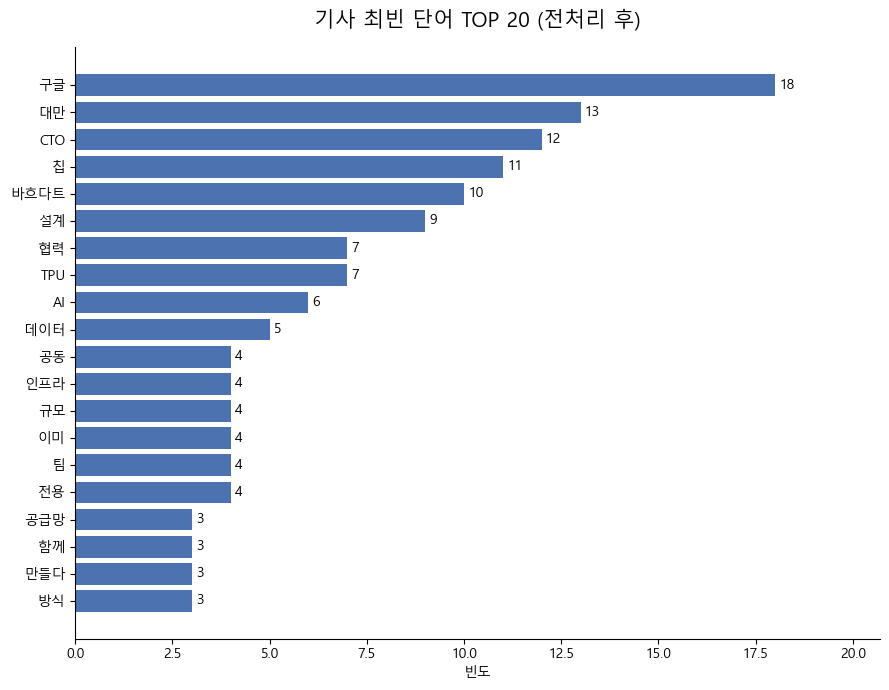

In [80]:
freq = Counter(final_tokens)
top20 = freq.most_common(20)

words  = [w for w, _ in top20][::-1]
counts = [c for _, c in top20][::-1]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(words, counts, color="#4C72B0")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("기사 최빈 단어 TOP 20 (전처리 후)", fontsize=15, pad=15)
ax.set_xlabel("빈도")
ax.set_xlim(0, max(counts) * 1.15)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

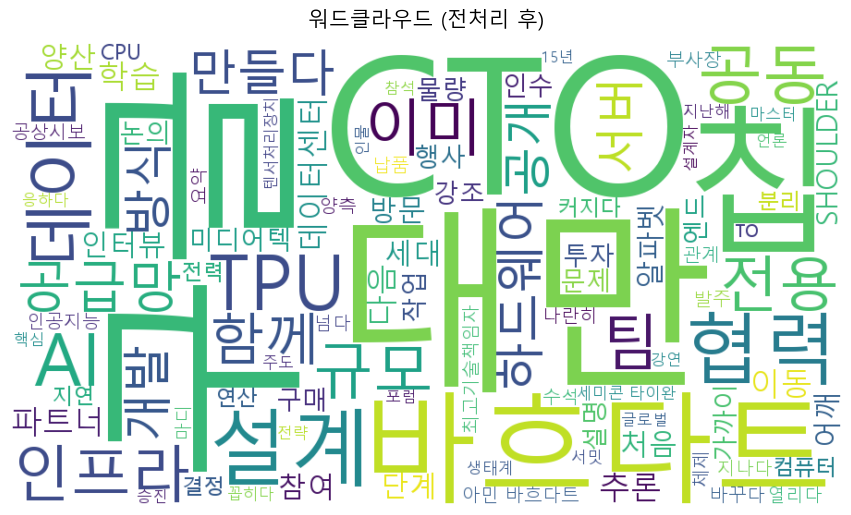

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(
    font_path=r'c:\WINDOWS\Fonts\MALGUN.TTF', # 윈도우 폰트 설치 경로
    width=900, height=500,
    background_color="white",
    colormap="viridis",
    max_words=100,
    relative_scaling=0.3,
).generate_from_frequencies(freq)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("워드클라우드 (전처리 후)", fontsize=15, pad=12)
plt.show()

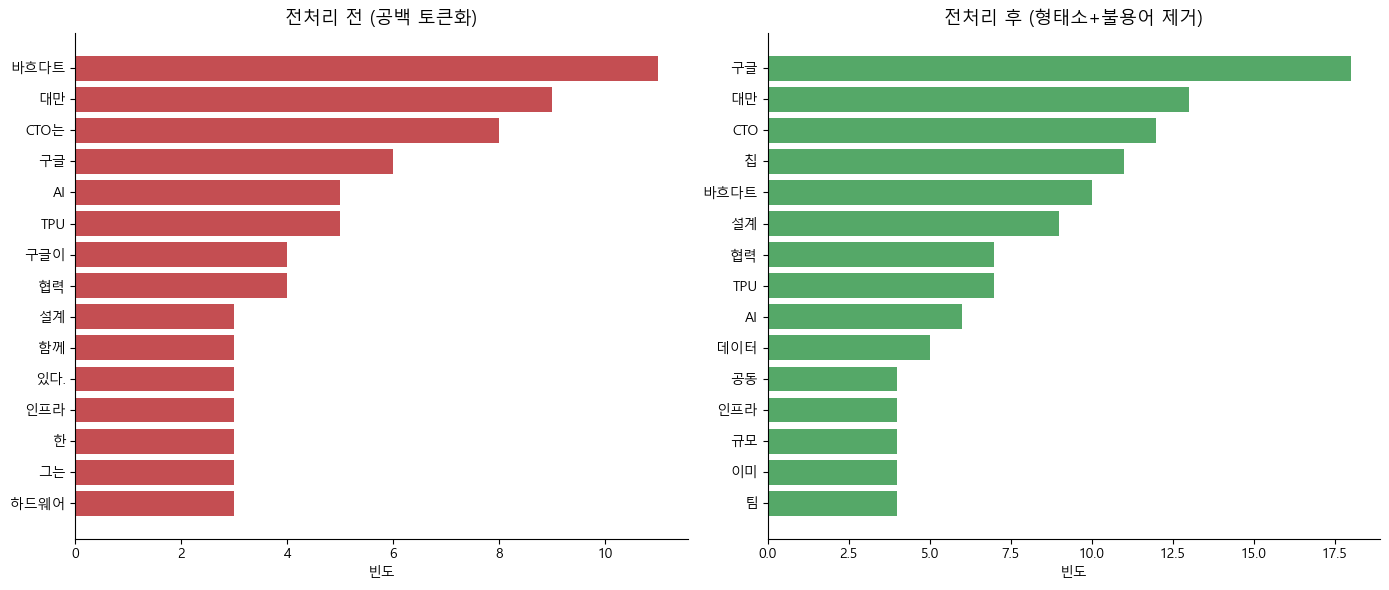

In [85]:
# 전처리 전(공백 토큰) vs 전처리 후 비교 -> 전처리 효과 확인
raw_freq = Counter(space_tokens).most_common(15)
new_freq = freq.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title, color in [
    (axes[0], raw_freq, "전처리 전 (공백 토큰화)", "#C44E52"),
    (axes[1], new_freq, "전처리 후 (형태소+불용어 제거)", "#55A868"),
]:
    w = [x for x, _ in data][::-1]
    c = [y for _, y in data][::-1]
    ax.barh(w, c, color=color)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("빈도")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# 상위 30개 단어 표로 정리
pd.DataFrame(freq.most_common(20), columns=["단어", "빈도"]).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
단어,구글,대만,CTO,칩,바흐다트,설계,협력,TPU,AI,데이터,공동,인프라,규모,이미,팀,전용,공급망,함께,만들다,방식
빈도,18,13,12,11,10,9,7,7,6,5,4,4,4,4,4,4,3,3,3,3


---

## 3. 전처리 결과에 대한 고찰

### 3.1 토큰화 과정에서 발생한 문제점과 해결 방안

**(1) 마침표가 문장의 끝이 아닌 경우**

`text.split(".")` 로 자르면 `2.5%` 같은 표현에서 문장이 잘못 끊긴다.  
`39억달러를 투자했다. 성장률은 2.5% 였다. 이는 예상치, i.e. 시장 컨센서스를 웃돈다.` 를 넣어보면  
단순 split은 5조각으로 **과분할** 되고 정규표현식은 3문장으로 정확히 나눌 수 있다.

- 해결 1 : 소수점·약어를 임시 토큰(`<DOT>`)으로 보호한 뒤 정규표현식으로 분리
- 해결 2 : 한국어 전용 문장 분리기 **kss(Korean Sentence Splitter)** 사용

**(2) 단어 토큰화 — 공백 기준의 한계**

한국어는 공백을 기준으로 토큰화 할 경우 `구글이 / 구글과 / 구글의 / 구글은` 이 전부 다른 토큰이 된다.  
그러므로 형태소 분석기를 활용하여 토큰화를 수행해야 한다.

**(3) 미등록어(OOV) — 고유명사가 분리되는 문제**

신조어·인명·제품명은 분석기 사전에 없기 때문에 발생하고 해결 방법은 다음과 같다.

| 방법 | 설명 |
|---|---|
| **사용자 사전(userdic)** | Komoran 은 `단어\tPOS` 파일을 지정할 수 있어 가장 간단하고 확실 |
| **Mecab-ko + 사전 추가** | 속도가 가장 빠르고 사전 커스터마이징 자유도 높음 (`konlpy.tag.Mecab`) |
| **soynlp** | 사전 없이 말뭉치 통계(응집확률)로 신조어를 자동 추출 — 대용량 데이터에 적합 |

**(4) 분석기 선택 자체가 결과를 바꾼다**

Okt / Komoran / Hannanum / Kkma 는 같은 문장에서도 서로 다른 결과를 낸다.  
Okt 는 구어체·SNS에, Komoran 은 사용자 사전이 필요한 뉴스·전문 문서에, Mecab 은 대용량 처리에 적합하다.  
**분석 목적에 맞는 분석기를 먼저 정하고, 부족한 부분을 사용자 사전으로 보완하는 순서**가 바람직하다.

---

### 3.2 원형 복원이 필요한 이유와, 하지 않았을 때의 문제점

**필요한 이유**

한국어 용언은 `말했다 / 말하고 / 말하며 / 말한 / 말할` 처럼 하나의 어간이 수십 가지로 활용된다.  
원형으로 통일하지 않으면 **같은 의미가 여러 개의 서로 다른 토큰으로 취급된다.**

**하지 않았을 때의 문제점**

1. **같은 의미, 다른 토큰** — `설명했다(1) + 설명하며(1) + 설명한(1)`로 분리되면   
   실제로 3회 등장한 핵심어가 상위권에 오르지 못한다. 즉 최빈어 시각화 결과 자체가 잘못된다.
2. **불용어 처리 실패** — 불용어 목록에 `하다` 만 넣어두면 `했다`, `하며`, `한` 은 걸러지지 않는다.  
   원형 복원이 선행되어야 불용어 사전이 제대로 동작한다.

---

### 3.3 불용어 목록을 직접 구성할 때 고려할 사항

1. **먼저 빈도를 확인하고 나서 고른다.**
   미리 만들어진 범용 불용어 리스트를 그대로 쓰면 도메인 핵심어를 지워버릴 수 있다.  
   상위 빈도수의 단어를 체크하고 제거 대상을 정하는 것이 안전하다.

2. **도메인에 따라 불용어가 달라진다.**
   `설계`(8회), `협력`(7회), `데이터`(5회) 는 일반 문서에서는 흔한 단어지만 이 기사에서는 핵심 주제어다.  
   반대로 `기자`, `사진`, `무단 전재`, `재배포 금지` 는 뉴스 도메인 특유의 상투어라 반드시 제거해야 한다.

3. **원형 복원 이후에 적용한다.**

4. **길이 기준에 예외를 추가한다.**
   "한 글자 토큰 제거"는 편리하지만 이 기사에서는 `칩`(11회, 전체 4위), `팀`(4회), `랙` 처럼  
   핵심 단어가 통째로 사라진다. 예외 목록(`KEEP_ONE_CHAR`)을 두어 보완한다.

5. **품사 기준과 단어 기준을 분리해서 관리한다.**
   조사·어미는 품사로 일괄 제거하고, 의미 품사 중 변별력 없는 단어만 사전으로 관리하면  
   목록이 짧아지고 유지보수가 쉬워진다.

6. **표기 변형을 함께 등록한다.**
   `AI / A.I. / 인공지능`, `TPU / tpu` 처럼 같은 대상의 다른 표기는 정규화(대소문자 통일 등)를
   먼저 해두어야 불용어/핵심어 처리가 일관된다.

7. **제거 → 확인 → 보완 사이클을 반복한다.**
   불용어 제거 → 빈도 재확인 → 목록 보완의 사이클을 몇 번 돌리면서 개선한다.

---

### 3.4 불용어를 제거하지 않으면 분석 결과에 미치는 영향

1. **최빈어가 조사·어미로 채워진다.**
   "전처리 전 vs 후" 비교 그래프에서 보이듯, 전처리 전에는 `대만`, `구글` 같은 주제어보다  
   조사가 붙은 어절들이 뒤섞여 기사의 주제를 전혀 읽어낼 수 없다.

2. **워드클라우드·분석 모델의 성능이 떨어진다.**
   키워드 추출에서 핵심 키워드가 `있다`, `하다`, `것` 같은 단어로 대표되어  
   중요 키워드를 뽑지 못할 수 있다.

3. **연산 비용과 메모리가 증가한다.**
   이 기사에서도 형태소 1,065개 중 최종 분석에 쓰인 토큰은 248개(38.8%)로, 60% 이상이 노이즈였다.  
   문서가 수만 건이 되면 어휘 사전 크기와 행렬 크기 차이가 그대로 학습 시간 차이로 이어진다.

4. **다만 과도한 제거는 정보 손실을 부른다.**
   부정 표현(`아니다`, `않다`)을 불용어로 지우면 감성 분석에서 문장의 의미가 정반대로 뒤집힌다.  
   불용어 목록은 **분석 목적에 따라 다르게 설정한다.**